In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/celeba-dataset


In [16]:
# prompt: create a list of image names

import os

# Assuming the images are in a subdirectory named 'img_align_celeba'
image_dir = os.path.join(path, 'img_align_celeba','img_align_celeba')

# List all files in the directory
image_files = os.listdir(image_dir)

# Filter out non-image files (optional, based on your file types)
image_names = [f for f in image_files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

image_names[1]


'168202.jpg'

In [17]:
import pandas as pd

df=pd.read_csv(os.path.join(path,'list_attr_celeba.csv'))
df

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202594,202595.jpg,-1,-1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1
202595,202596.jpg,-1,-1,-1,-1,-1,1,1,-1,-1,...,-1,1,1,-1,-1,-1,-1,-1,-1,1
202596,202597.jpg,-1,-1,-1,-1,-1,-1,-1,-1,1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
202597,202598.jpg,-1,1,1,-1,-1,-1,1,-1,1,...,-1,1,-1,1,1,-1,1,-1,-1,1


In [18]:
df=df[['image_id','Male']]
df

,image_id,Male
0,000001.jpg,-1
1,000002.jpg,-1
2,000003.jpg,1
3,000004.jpg,-1
4,000005.jpg,-1
...,...,...
202594,202595.jpg,-1
202595,202596.jpg,1
202596,202597.jpg,1
202597,202598.jpg,-1


In [19]:
df['Male'].value_counts()

,count
Male,
-1,118165
1,84434


In [6]:
df['image_id']=path+'/img_align_celeba/img_align_celeba/'+df['image_id']

<ipython-input-6-0dbec2ba1496>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['image_id']=path+'/img_align_celeba/img_align_celeba/'+df['image_id']


In [20]:
# prompt: show random images in df

import matplotlib.pyplot as plt
import random

# Select a random sample of images
num_images_to_show = 5  # Change this to show more or fewer images
random_indices = random.sample(range(len(df)), num_images_to_show)
random_images = df.iloc[random_indices]

# Display the images
for index, row in random_images.iterrows():
    image_path = row['image_id']
    try:
        img = plt.imread(image_path)
        plt.imshow(img)
        plt.title(f"Image ID: {row['image_id']}, Male: {row['Male']}")
        plt.axis('off')  # Turn off axis labels
        plt.show()
    except FileNotFoundError:
        print(f"Image file not found: {image_path}")
    except Exception as e:
        print(f"Error displaying image {image_path}: {e}")


Image file not found: 133092.jpg
Image file not found: 074523.jpg
Image file not found: 026552.jpg
Image file not found: 028171.jpg
Image file not found: 092507.jpg


In [21]:
df

,image_id,Male
0,000001.jpg,-1
1,000002.jpg,-1
2,000003.jpg,1
3,000004.jpg,-1
4,000005.jpg,-1
...,...,...
202594,202595.jpg,-1
202595,202596.jpg,1
202596,202597.jpg,1
202597,202598.jpg,-1


In [22]:
# prompt: remove 1/2 rows of df

import pandas as pd
# Assuming 'df' is your DataFrame from the previous code
# Example usage (replace with your actual df)
#df = pd.DataFrame({'A': range(10)})

# Calculate the number of rows to remove
rows_to_remove = len(df) * 0.9

# Randomly select indices to remove
indices_to_remove = df.sample(n=int(rows_to_remove)).index

# Remove the selected rows
df = df.drop(indices_to_remove)

# Print the reduced DataFrame
df


,image_id,Male
23,000024.jpg,-1
29,000030.jpg,1
32,000033.jpg,1
47,000048.jpg,1
51,000052.jpg,1
...,...,...
202563,202564.jpg,-1
202584,202585.jpg,1
202585,202586.jpg,1
202590,202591.jpg,-1


In [23]:
df['Male'].value_counts()

,count
Male,
-1,11802
1,8458


In [11]:
# prompt: split random df

from sklearn.model_selection import train_test_split

# Assuming 'df' is your DataFrame
train_df, test_df = train_test_split(df, test_size=0.25, random_state=42)
print(f"Train set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")


Train set size: 15195
Test set size: 5065


In [24]:
df.dtypes

,0
image_id,object
Male,int64


In [13]:
train_df['Male'] = train_df['Male'].astype(str)
test_df['Male'] = test_df['Male'].astype(str)

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Set the image size and batch size
image_size = (75, 75)
batch_size = 512

# Create an ImageDataGenerator object with data augmentation options for image preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    # rotation_range=45,
    # width_shift_range=0.2,
    # height_shift_range=0.2,
    # shear_range=0.2,
    # zoom_range=0.2,
    # horizontal_flip=True,
    # fill_mode='nearest'
)


# Create a generator for the training data
train_generator = datagen.flow_from_dataframe(
    train_df,
    x_col='image_id',
    y_col='Male',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Create a generator for the test data
test_generator = datagen.flow_from_dataframe(
    test_df,
    x_col='image_id',
    y_col='Male',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 15195 validated image filenames belonging to 2 classes.
Found 5065 validated image filenames belonging to 2 classes.


In [26]:
from tensorflow import keras
from tensorflow.keras import layers
def AlexNet(input_shape, num_classes):
    model = keras.Sequential(
        [
            keras.Input(shape=input_shape),
            layers.Conv2D(96, kernel_size=(11, 11), strides=4, padding="valid", activation="relu"),
            layers.MaxPooling2D(pool_size=(3, 3), strides=2),
            layers.BatchNormalization(),
            layers.Conv2D(256, kernel_size=(5, 5), padding="same", activation="relu"),
            layers.MaxPooling2D(pool_size=(3, 3), strides=2),
            layers.BatchNormalization(),
            layers.Conv2D(384, kernel_size=(3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(384, kernel_size=(3, 3), padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(256, kernel_size=(3, 3), padding="same", activation="relu"),
            layers.MaxPooling2D(pool_size=(2,2), strides=2),
            layers.BatchNormalization(),
            layers.Flatten(),
            layers.Dense(4096, activation="relu"),
            layers.Dropout(0.5),
            layers.Dense(4096, activation="relu"),
            layers.Dropout(0.5),
            layers.Dense(num_classes, activation="softmax"),
        ]
    )
    return model

input_shape = (75, 75, 3)
num_classes = 2  # Number of yoga poses

model = AlexNet(input_shape, num_classes)
model.summary()

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Train the model
epochs = 15  # You can adjust the number of epochs
history = model.fit(train_generator, epochs=epochs, validation_data=test_generator)


# Evaluate the model
loss, accuracy = model.evaluate(test_generator, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 17, 17, 96)          │          34,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 96)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 8, 8, 96)            │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 8, 8, 256)           │         614,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 3, 3, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 3, 3, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 3, 3, 384)           │         885,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 3, 3, 384)           │           1,536 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 3, 3, 384)           │       1,327,488 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 3, 3, 384)           │           1,536 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 3, 3, 256)           │         884,992 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 1, 1, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 1, 1, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 4096)                │       1,052,672 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 4096)                │      16,781,312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 2)                   │           8,1

 Total params: 21,594,882 (82.38 MB)

 Trainable params: 21,592,130 (82.37 MB)

 Non-trainable params: 2,752 (10.75 KB)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 971ms/step - accuracy: 0.6325 - loss: 1.5537 - val_accuracy: 0.5872 - val_loss: 0.8331
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 753ms/step - accuracy: 0.8728 - loss: 0.2974 - val_accuracy: 0.5876 - val_loss: 1.3227
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 767ms/step - accuracy: 0.9156 - loss: 0.2006 - val_accuracy: 0.6209 - val_loss: 0.8412
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 779ms/step - accuracy: 0.9411 - loss: 0.1485 - val_accuracy: 0.8190 - val_loss: 0.3663
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 737ms/step - accuracy: 0.9538 - loss: 0.1165 - val_accuracy: 0.6375 - val_loss: 1.0632
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 23s 770ms/step - accuracy: 0.9644 - loss: 0.0973 - val_accuracy: 0.8381 - val_loss: 0.3506
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 737ms/step - accuracy: 0.9683 - loss: 0.0802 - val_accuracy: 0.8460 - val_loss: 0.3685
Epoch 8/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 22s 752ms/step - accuracy: 0.9729 - loss: 0.0698 - val_accu

In [27]:
# prompt: show img with path

import matplotlib.pyplot as plt
import os



def show_image_with_path(image_path):
    try:
        img = plt.imread(image_path)
        plt.imshow(img)
        plt.title(f"Image Path: {image_path}")
        plt.axis('off')  # Turn off axis labels
        plt.show()
    except FileNotFoundError:
        print(f"Image file not found: {image_path}")
    except Exception as e:
        print(f"Error displaying image {image_path}: {e}")






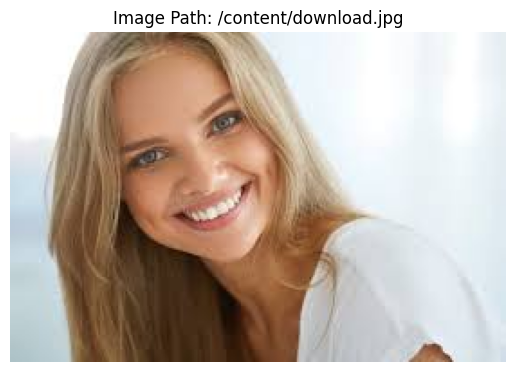

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
[[0.65462464 0.3453754 ]]
Predicted class: FeMale


In [42]:
# prompt: predict with model method

import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(image_path, model):
  show_image_with_path(image_path)
  img = image.load_img(image_path, target_size=(75, 75))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)
  x = x / 255.0  # Rescale the image
  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)
  print(classes)
  predicted_class = np.argmax(classes)
  if predicted_class == 0:
    return 'Female'
  else:
    return 'male'

# Example usage (assuming you have a trained model named 'model'):
predicted_class = predict_image('/content/download.jpg', model)
print(f"Predicted class: {predicted_class}")


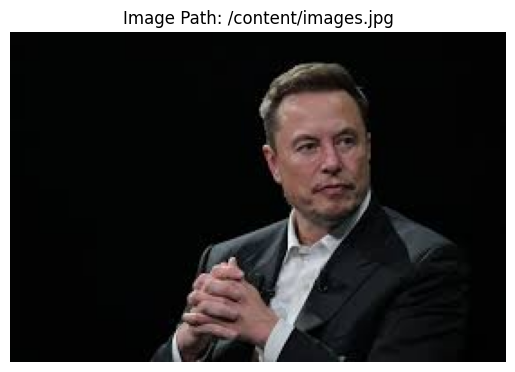

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[0.35618475 0.6438153 ]]
Predicted class: male


In [50]:
# Example usage (assuming you have a trained model named 'model'):
predicted_class = predict_image('/content/images.jpg', model)
print(f"Predicted class: {predicted_class}")